In [151]:
import numpy as np # Used for handling numerical arrays
import matplotlib.pyplot as plt # Standard tool for creating plots
import seaborn as sns # Built on top of matplotlib for prettier statistical plots
sns.set_theme() # Set default styles for our plots

## 1. Setup Data
We define our input feature `X` (Years of Experience) and our target label `y` (Salary).

In [152]:
# X represents our 'Feature' (the data we use to make predictions)
X = np.array([1 , 3, 4, 6, 7]) # Years of experience

# y represents our 'Target' (the value we want our model to learn to predict)
y = np.array([15, 35, 45, 65, 75]) # Salary in thousands

## 2. Visualize the Raw Data
Before modeling, we look at the data points to see if a correlateion exist

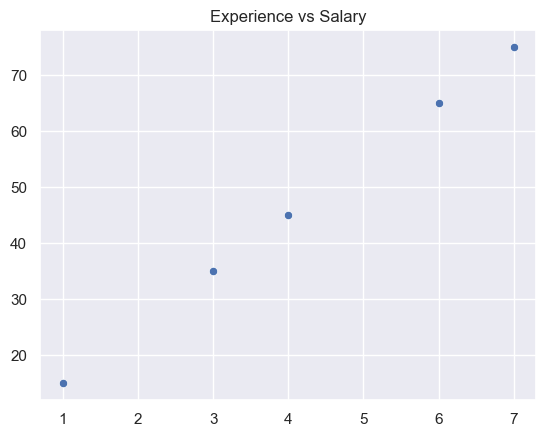

In [153]:
# Create a scatter plot to see the relationship between X and y
sns.scatterplot(x=X, y=y)
plt.title("Experience vs Salary")
plt.show()

## 3. Defining the Prediction Function
The function below implements the linear formula for every data point.
- `w` (weight) controls the slope.
- `b` (bias) controls the y-intercept.

In [154]:
def make_prediction(X,y,w,b): 
    m = X.shape[0]

    pred_list = np.zeros((m,))

    for i in range(m):
        pred_list[i] = w * X[i] + b
    return pred_list

## 4. Experimenting with Parameters
Now we test different values of `w` and `b` to see how well our line fits the data.

In [155]:
predictions = make_prediction(X,y,0,0)
print(predictions)

[0. 0. 0. 0. 0.]


<Axes: >

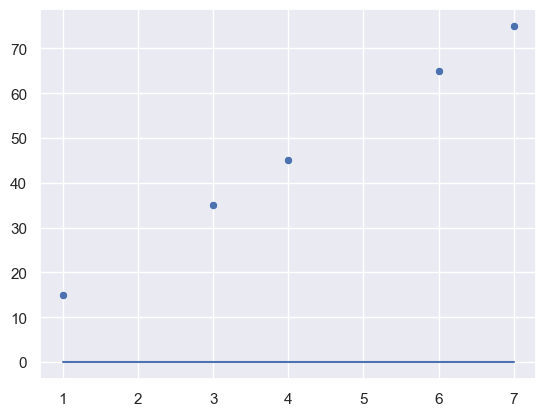

In [156]:
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)

### Case 1: Minimal values
Here $w=1, b=0$. The line is far below the data points.

In [157]:
predictions = make_prediction(X,y,w=1,b=0)
print(predictions)

[1. 3. 4. 6. 7.]


<Axes: >

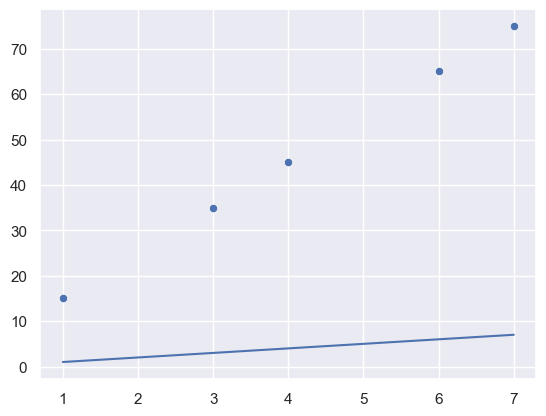

In [158]:
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)

### Case 2: Increasing the slope
Using $w=5, b=3$ brings the line closer, but it's still not quite there.

In [159]:
predictions = make_prediction(X,y,w=5,b=3)
print(predictions)

[ 8. 18. 23. 33. 38.]


<Axes: >

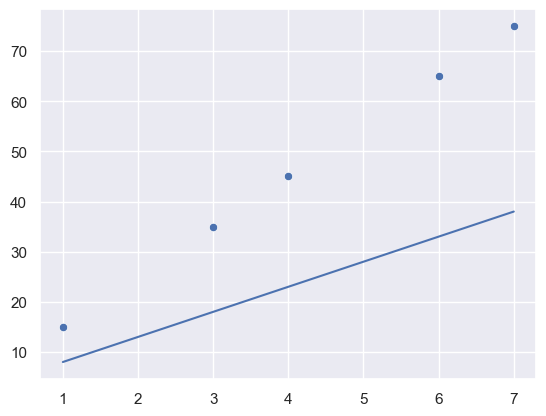

In [160]:
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)

In [161]:
predictions = make_prediction(X,y,w=10,b=5)
print(predictions)

[15. 35. 45. 65. 75.]


<Axes: >

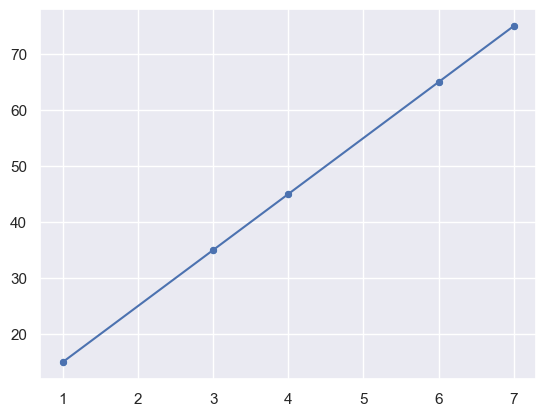

In [162]:
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)

## Summary
In this notebook, we manually explored how a linear regression model makes predictions. Here are the key takeaways:

1. **Model Parameters**: We saw that $w$ (the weight) controls the steepness or slope of the line, while $b$ (the bias) shifts the line up or down on the y-axis.

2.  When our parameters were too small (like $w=1, b=0$), the line failed to capture the trend of the data.


3. **Finding the 'Best Fit'**: By iterating through different values, we found that $w=10$ and $b=5$ perfectly matched our small dataset. In a real ML project, we use an algorithm called **Gradient Descent** to find these optimal values automatically by minimizing a 'Cost Function'.

We will learn the Cost function code and Gradient Descent in the next module.

## Module 10: Simple Linear Regression Implementation and Gradient Descent

### 10.2 Implementation of cost function

In [163]:
def compute_cost(X,y,w,b): 
    m = X.shape[0] # number of data points
    cost = 0.0 
    
    for i in range(m): 
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_squared = error ** 2 
        cost = cost + error_squared 
    cost = cost / m
    
    return cost

[0. 0. 0. 0. 0.]


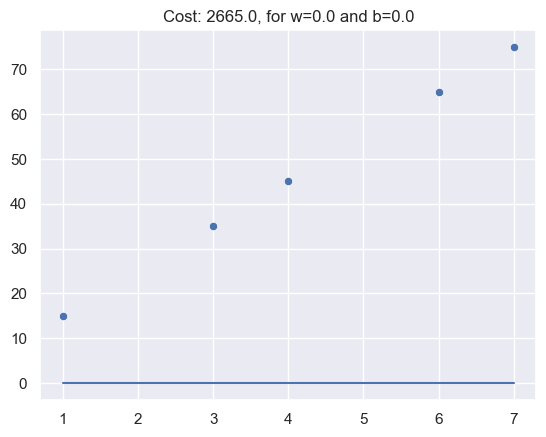

In [164]:
w= 0.0 
b= 0.0

predictions = make_prediction(X,y,w=w,b=b) 
print(predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}")
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)
plt.show()

[1. 3. 4. 6. 7.]


<Axes: title={'center': 'Cost: 2201.2, for w=1.0 and b=0.0'}>

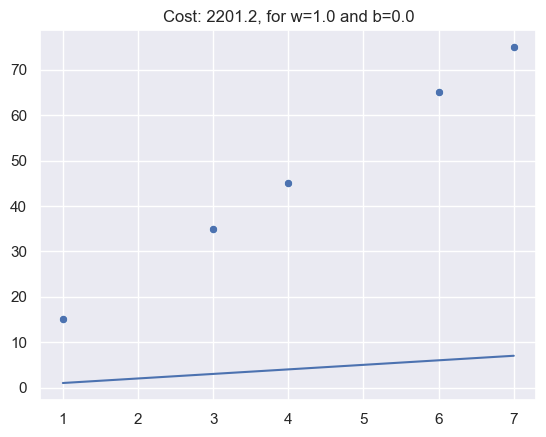

In [165]:
w= 1.0
b= 0.0

predictions = make_prediction(X,y,w=w,b=b) 
print(predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}")
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)

[ 3.  7.  9. 13. 15.]


<Axes: title={'center': 'Cost: 1705.6, for w=2.0 and b=1.0'}>

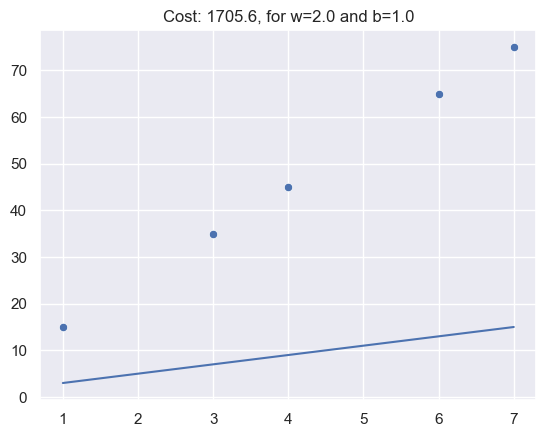

In [166]:
w= 2.0
b= 1.0

predictions = make_prediction(X,y,w=w,b=b) 
print(predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}")
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)

[ 5. 11. 14. 20. 23.]


<Axes: title={'center': 'Cost: 1273.2, for w=3.0 and b=2.0'}>

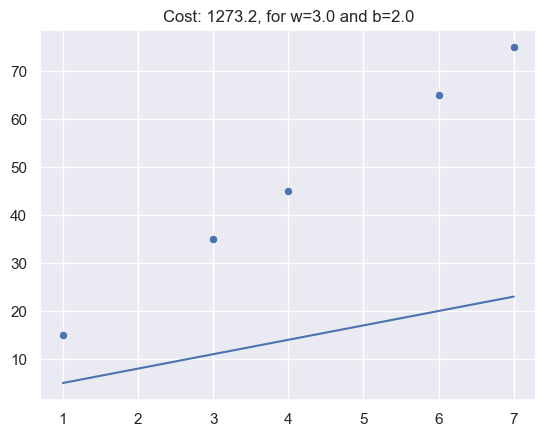

In [167]:
w= 3.0
b= 2.0

predictions = make_prediction(X,y,w=w,b=b) 
print(predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}")
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)

[15. 35. 45. 65. 75.]


<Axes: title={'center': 'Cost: 0.0, for w=10.0 and b=5.0'}>

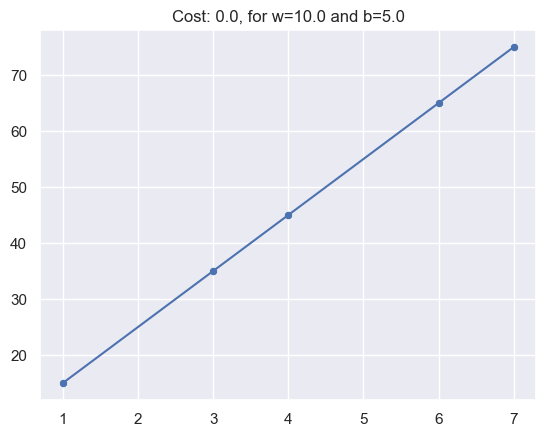

In [168]:
w= 10.0
b= 5.0

predictions = make_prediction(X,y,w=w,b=b) 
print(predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}")
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)

### 10.3 Idea of Minimizing the cost function

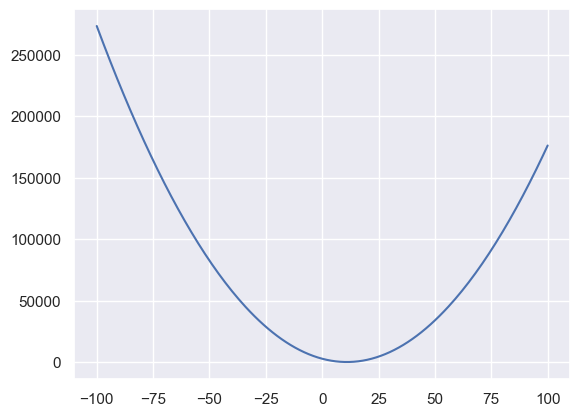

In [169]:
w = []
cost = [] 

# w-> -100-> 1- 

for i in range(-100,101):
    cost_i = compute_cost(X,y,w=i,b=0)
    w.append(i)
    cost.append(cost_i) 
plt.plot(w,cost)
 

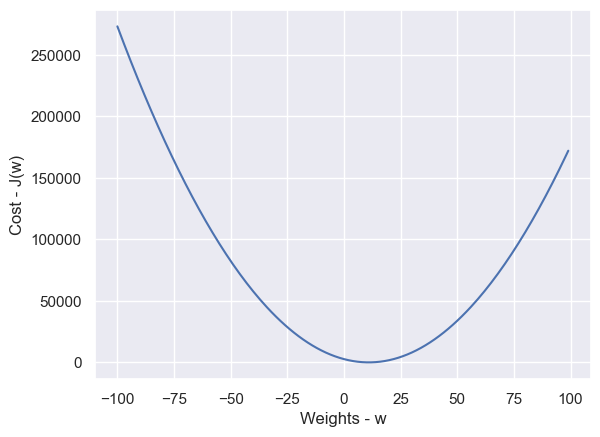

In [170]:
w = []
cost = [] 

# w-> -100-> 1- 

for i in range(-100,100):
    cost_i = compute_cost(X,y,w=i,b=0)
    w.append(i)
    cost.append(cost_i) 
    
plt.xlabel("Weights - w")
plt.ylabel("Cost - J(w)")
plt.plot(w,cost)
plt.show() 

### 10.6 Calcualation of Gradient


In [171]:
def calculate_gradient(X,y,w,b): 
    m = X.shape[0] # number of data points
    dj_dw = 0.0
    dj_db = 0.0
    
    for i in range(m): 
        prediction = w * X[i] + b
        error = prediction - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error 

    dj_dw = dj_dw / m 
    dj_db = dj_db / m
    return dj_dw,dj_db

 



In [172]:
calculate_gradient(X,y,w=3,b=0)

(np.float64(-176.4), np.float64(-34.4))

### 10.7 Applying Gradient Descent to minimize cost and Final Prediction

In [173]:
def gradient_descent(X,y,w_input,b_input,max_iter,alpha=0.01): 
    
    w = w_input 
    b = b_input 
    cost_memo = []
    iteration = []
    for i in range(max_iter): 
        dj_dw,dj_db = calculate_gradient(X,y,w,b) 

        #update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db 

        cost = compute_cost(X,y,w,b) 

        cost_memo.append(cost) 
        iteration.append(i)

        if i%100 == 0: 
            print(f"w:{w},b:{b}, dj_dw:{dj_dw},dj_db:{dj_db},cost:{cost}") 

    return w,b,cost_memo,iteration

In [174]:
w,b,memo,iter = gradient_descent(X,y,w_input=0,b_input=0,max_iter=10000,alpha=0.01)

w:2.43,b:0.47000000000000003, dj_dw:-243.0,dj_db:-47.0,cost:1580.74332
w:10.46591953814626,b:2.5592744809869727, dj_dw:0.09255004327219787,dj_db:-0.48482460301141933,cost:1.2240132798411674
w:10.382057239261956,b:2.9985882171300546, dj_dw:0.0758916755823165,dj_db:-0.39755952282351215,cost:0.8230403937464479
w:10.313289574937954,b:3.358828514956577, dj_dw:0.062231698136283244,dj_db:-0.32600155452757174,cost:0.5534216833221024
w:10.256899615236728,b:3.6542280472350646, dj_dw:0.05103042228553463,dj_db:-0.2673235262976597,cost:0.3721270084654254
w:10.210659458814899,b:3.896457703930417, dj_dw:0.041845298724391,dj_db:-0.219207137879377,cost:0.25022241556955654
w:10.172742211183513,b:4.095087695420831, dj_dw:0.03431343396565616,dj_db:-0.17975136705238093,cost:0.168252386494759
w:10.141649806243873,b:4.257965660314708, dj_dw:0.028137252843392347,dj_db:-0.14739736246626728,cost:0.11313481047149745
w:10.116153819448396,b:4.391526716471991, dj_dw:0.023072741666278773,dj_db:-0.12086685524723464,c

In [175]:
def gradient_descent(X,y,w_input,b_input,max_iter,alpha=0.01): 
    
    w = w_input 
    b = b_input 
    cost_memo = []
    iteration = []
    for i in range(max_iter): 
        dj_dw,dj_db = calculate_gradient(X,y,w,b) 

        #update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db 

        cost = compute_cost(X,y,w,b) 

        cost_memo.append(cost) 
        iteration.append(i)

        if i%100 == 0: 
            print(f"iteration:{i},w:{w:0.4f},b:{b:0.4f}, dj_dw:{dj_dw:0.4f},dj_db:{dj_db:0.4f},cost:{cost:0.4f}") 

    return w,b,cost_memo,iteration

In [176]:
w,b,memo,iter = gradient_descent(X,y,w_input=0,b_input=0,max_iter=10000,alpha=0.01)

iteration:0,w:2.4300,b:0.4700, dj_dw:-243.0000,dj_db:-47.0000,cost:1580.7433
iteration:100,w:10.4659,b:2.5593, dj_dw:0.0926,dj_db:-0.4848,cost:1.2240
iteration:200,w:10.3821,b:2.9986, dj_dw:0.0759,dj_db:-0.3976,cost:0.8230
iteration:300,w:10.3133,b:3.3588, dj_dw:0.0622,dj_db:-0.3260,cost:0.5534
iteration:400,w:10.2569,b:3.6542, dj_dw:0.0510,dj_db:-0.2673,cost:0.3721
iteration:500,w:10.2107,b:3.8965, dj_dw:0.0418,dj_db:-0.2192,cost:0.2502
iteration:600,w:10.1727,b:4.0951, dj_dw:0.0343,dj_db:-0.1798,cost:0.1683
iteration:700,w:10.1416,b:4.2580, dj_dw:0.0281,dj_db:-0.1474,cost:0.1131
iteration:800,w:10.1162,b:4.3915, dj_dw:0.0231,dj_db:-0.1209,cost:0.0761
iteration:900,w:10.0952,b:4.5010, dj_dw:0.0189,dj_db:-0.0991,cost:0.0512
iteration:1000,w:10.0781,b:4.5909, dj_dw:0.0155,dj_db:-0.0813,cost:0.0344
iteration:1100,w:10.0640,b:4.6645, dj_dw:0.0127,dj_db:-0.0666,cost:0.0231
iteration:1200,w:10.0525,b:4.7249, dj_dw:0.0104,dj_db:-0.0546,cost:0.0156
iteration:1300,w:10.0431,b:4.7744, dj_dw:0.0

In [177]:
def gradient_descent(X,y,w_input,b_input,max_iter,alpha=0.01): 
    
    w = w_input 
    b = b_input 
    cost_memo = []
    iteration = []
    for i in range(max_iter): 
        dj_dw,dj_db = calculate_gradient(X,y,w,b) 

        #update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db 

        cost = compute_cost(X,y,w,b) 

        cost_memo.append(cost) 
        iteration.append(i)

        if i%100 == 0: 
            print(f"Iteration:{i} w:{w:0.4f},b:{b:0.4f}, dj_dw:{dj_dw:0.4f}, dj_db:{dj_db:0.4f},cost:{cost:0.4f}") 

    return w,b,cost_memo,iteration

In [178]:
w_final,b_final,cost_memo,iter = gradient_descent(X,y,w_input=-100,b_input=-100,max_iter=10000,alpha=0.01)

Iteration:0 w:-71.1700,b:-94.3300, dj_dw:-2883.0000, dj_db:-567.0000,cost:223858.6537
Iteration:100 w:22.6617,b:-61.3284, dj_dw:2.5151, dj_db:-13.1754,cost:903.9549
Iteration:200 w:20.3827,b:-49.3897, dj_dw:2.0624, dj_db:-10.8039,cost:607.8295
Iteration:300 w:18.5139,b:-39.5999, dj_dw:1.6912, dj_db:-8.8593,cost:408.7115
Iteration:400 w:16.9814,b:-31.5723, dj_dw:1.3868, dj_db:-7.2647,cost:274.8222
Iteration:500 w:15.7248,b:-24.9895, dj_dw:1.1372, dj_db:-5.9571,cost:184.7936
Iteration:600 w:14.6944,b:-19.5916, dj_dw:0.9325, dj_db:-4.8849,cost:124.2573
Iteration:700 w:13.8494,b:-15.1653, dj_dw:0.7646, dj_db:-4.0056,cost:83.5520
Iteration:800 w:13.1566,b:-11.5357, dj_dw:0.6270, dj_db:-3.2846,cost:56.1813
Iteration:900 w:12.5884,b:-8.5594, dj_dw:0.5142, dj_db:-2.6934,cost:37.7770
Iteration:1000 w:12.1225,b:-6.1188, dj_dw:0.4216, dj_db:-2.2086,cost:25.4017
Iteration:1100 w:11.7405,b:-4.1175, dj_dw:0.3457, dj_db:-1.8111,cost:17.0804
Iteration:1200 w:11.4272,b:-2.4764, dj_dw:0.2835, dj_db:-1.4

10.000000037263751 4.999999804793351
[14.99999999 35.         45.         65.         75.        ]


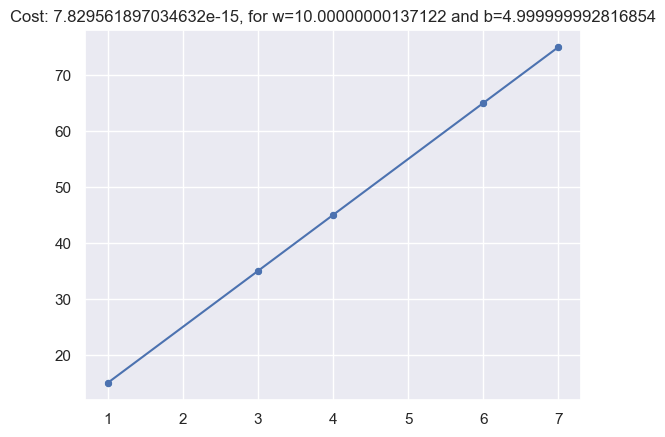

In [179]:
print(w_final,b_final)

predictions = make_prediction(X,y,w=w,b=b) 
print(predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w_final,b=b_final)}, for w={w} and b={b}")
plt.plot(X,predictions)
sns.scatterplot(x=X,y=y)
plt.show()

In [180]:
x = 2
prediction = w_final * x + b_final 
print(prediction)

24.999999879320853


### 10.8 Iteration vs Cost graph

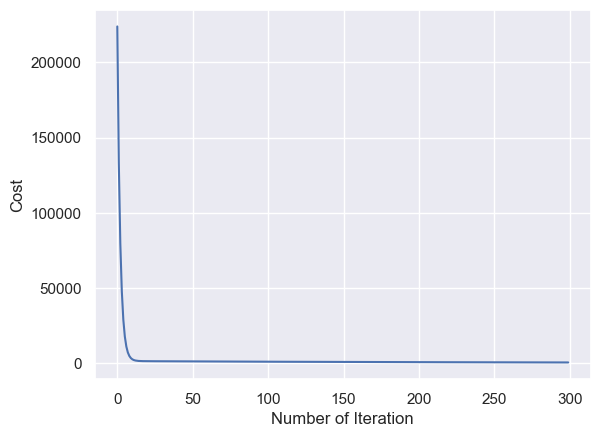

In [181]:
plt.xlabel("Number of Iteration")
plt.ylabel("Cost")

plt.plot(iter[:300],cost_memo[:300])
plt.show()

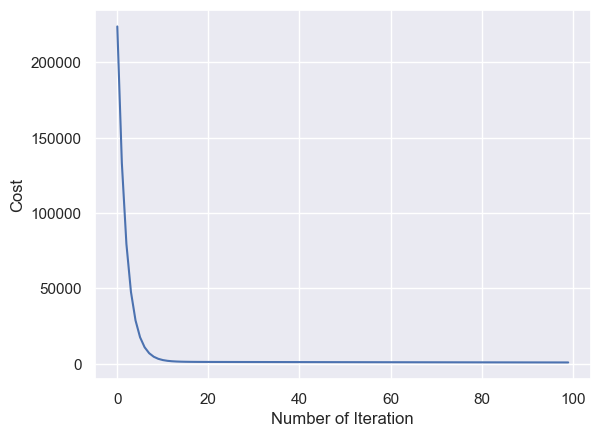

In [182]:
plt.xlabel("Number of Iteration")
plt.ylabel("Cost")

plt.plot(iter[:100],cost_memo[:100])
plt.show()

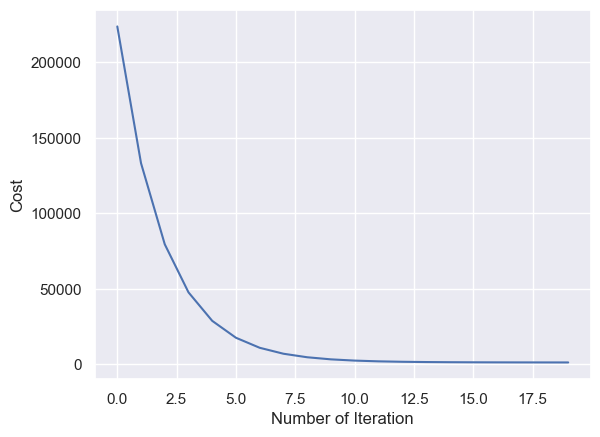

In [183]:
plt.xlabel("Number of Iteration")
plt.ylabel("Cost")

plt.plot(iter[:20],cost_memo[:20])
plt.show()